# Exploring PyTorch

PyTorch is the other major deep learning library, alongside TensorFlow, and the two solve the same problems with noticeably different design choices. If you've been through [ExploreTF.ipynb](./ExploreTF.ipynb), the fastest way to learn PyTorch is by contrast:

- TensorFlow splits data into immutable `tf.constant` and mutable, trainable `tf.Variable`. PyTorch doesn't — everything is a `torch.Tensor`, and tensors are mutable by default (unlike TF's `tf.constant`).
- TensorFlow tracks gradients only inside an explicit `with tf.GradientTape():` block. PyTorch tracks gradients on any tensor created with `requires_grad=True`, automatically, for as long as it's involved in computation.
- TensorFlow's `tape.gradient(y, x)` computes a gradient without changing `x`. PyTorch's `y.backward()` *accumulates* the gradient into `x.grad`, which means you must remember to zero it out between training steps — a very common early bug.

This notebook rebuilds the same progression as the TensorFlow one — tensors, gradients, a manual training loop, then the higher-level `nn`/`optim`/`DataLoader` tools and a real dataset — so you can see where the two frameworks agree and where they genuinely differ.

Before running, select the **TensorFlow** conda environment as this notebook's kernel (top-right kernel picker in VS Code) — PyTorch is already installed there alongside TensorFlow.

## 1. Setup

Import PyTorch and check the version plus whether it sees a GPU (via CUDA). Same story as the TensorFlow notebook: this environment is CPU-only, so `torch.cuda.is_available()` will print `False` — expected, not a bug, and plenty fast for everything here.

In [1]:
import numpy as np
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.14.0+cpu
CUDA available: False


## 2. Tensors: the core data structure

Same mental model as TensorFlow: a `torch.Tensor` is a grid of numbers with a shape (scalar, vector, matrix, and beyond) and a dtype. The one real difference worth internalizing now: **PyTorch tensors are mutable**. You can modify one in place, whereas `tf.constant` always hands you back a new tensor. In-place operations in PyTorch are conventionally marked with a trailing underscore — e.g. `.add_()` modifies in place, `.add()` returns a new tensor.

In [2]:
scalar = torch.tensor(7)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1, 2], [3, 4]])

for name, t in [("scalar", scalar), ("vector", vector), ("matrix", matrix)]:
    print(f"{name}: shape={t.shape}, dtype={t.dtype}\n{t}\n")

scalar: shape=torch.Size([]), dtype=torch.int64
7

vector: shape=torch.Size([3]), dtype=torch.float32
tensor([1., 2., 3.])

matrix: shape=torch.Size([2, 2]), dtype=torch.int64
tensor([[1, 2],
        [3, 4]])



As in TensorFlow, `*` is element-wise multiplication and `@` (or `torch.matmul`) is matrix multiplication — the same two operations, same distinction, just a different library. Then a quick demonstration of mutability: `.add_()` changes `mutable_example` in place, which simply isn't possible with a TF `tf.constant`.

In [3]:
a = [[1, 2], [2, 4]]
b = [1, 2]

a_t = torch.as_tensor(a, dtype=torch.float)
b_t = torch.as_tensor(b, dtype=torch.float)

a_t @ b_t  # Matrix-vector multiplication
a_transpose = a_t.T

In [4]:
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])

print("a + b:\n", a + b)
print("\nelement-wise a * b:\n", a * b)
print("\nmatrix multiply a @ b:\n", a @ b)

# PyTorch tensors are mutable -- this changes mutable_example in place
mutable_example = torch.tensor([1.0, 2.0, 3.0])
print("\nbefore add_:", mutable_example)
mutable_example.add_(10)
print("after add_: ", mutable_example)

a + b:
 tensor([[ 6,  8],
        [10, 12]])

element-wise a * b:
 tensor([[ 5, 12],
        [21, 32]])

matrix multiply a @ b:
 tensor([[19, 22],
        [43, 50]])

before add_: tensor([1., 2., 3.])
after add_:  tensor([11., 12., 13.])


## 3. Tensors interoperate with NumPy

Just like TensorFlow: `torch.from_numpy(array)` wraps a NumPy array as a tensor, and `.numpy()` unwraps a tensor back. PyTorch goes a step further, though — on CPU, the two **share the same underlying memory**, so converting is essentially free, and modifying one actually modifies the other. That's worth seeing directly rather than just stating, since it's a sharper distinction than in TensorFlow.

In [5]:
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])

tensor_from_np = torch.from_numpy(np_array)   # NumPy -> Tensor (shares memory on CPU)
back_to_np = tensor_from_np.numpy()           # Tensor -> NumPy (also shares memory)

print(type(tensor_from_np), "\n", tensor_from_np)
print(type(back_to_np), "\n", back_to_np)

# Prove they share memory: modifying the tensor in place changes the NumPy array too
tensor_from_np.add_(100)
print("\nafter tensor_from_np.add_(100), np_array is now:\n", np_array)

<class 'torch.Tensor'> 
 tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)
<class 'numpy.ndarray'> 
 [[1. 2.]
 [3. 4.]]

after tensor_from_np.add_(100), np_array is now:
 [[101. 102.]
 [103. 104.]]


## 4. Autograd: `requires_grad` and `.backward()`

In the TensorFlow notebook, "trainable, mutable numbers" (`tf.Variable`) and "recording operations to compute gradients" (`tf.GradientTape`) were two separate concepts. PyTorch merges them into one: **autograd**.

- Create a tensor with `requires_grad=True` and PyTorch automatically tracks every operation performed on it, building a computation graph as you go (this is called "define-by-run" — the graph is just whatever code actually executed, not a separate structure you build first).
- Call `.backward()` on a final scalar (typically a loss) and PyTorch walks that graph backward, computing gradients via the chain rule — same math as `tape.gradient`, different API.
- The result lands in `.grad` on each tracked tensor, rather than being returned directly.

One PyTorch-specific gotcha: gradients **accumulate** in `.grad` by default rather than being overwritten. Call `.backward()` twice without clearing `.grad` in between and you get the *sum* of both gradients, not the second one alone. The example below deliberately triggers this, then shows `.grad.zero_()` fixing it — this trips up nearly everyone the first time they hit it, so better to see it now on purpose.

Same example as before: for $y = x^2$, $\frac{dy}{dx} = 2x$, so at $x = 3$ we expect a gradient of $6$.

In [6]:
x = torch.tensor(3.0, requires_grad=True)

y = x ** 2
y.backward()
print("y =", y.item())
print("dy/dx =", x.grad.item(), "(expected 6)")

# Gotcha: calling backward() again ACCUMULATES into x.grad instead of replacing it
y2 = x ** 2
y2.backward()
print("\nafter a second backward() without zeroing grad:")
print("dy/dx =", x.grad.item(), "<- wrong! this is 6 + 6, not 6")

x.grad.zero_()
y3 = x ** 2
y3.backward()
print("\nafter x.grad.zero_() and a fresh backward():")
print("dy/dx =", x.grad.item(), "<- correct again")

y = 9.0
dy/dx = 6.0 (expected 6)

after a second backward() without zeroing grad:
dy/dx = 12.0 <- wrong! this is 6 + 6, not 6

after x.grad.zero_() and a fresh backward():
dy/dx = 6.0 <- correct again


## 5. Putting it together: a tiny training loop

Same task as the TensorFlow notebook, same data (same random seed, even), so you can compare the two directly: fit `y = w * x + b` to noisy points generated from `y = 2x + 1`, learning `w` and `b` from scratch.

The loop looks almost identical to the TensorFlow version conceptually (predict → measure error → compute gradients → update), but every line reflects the differences from section 4:

- `loss.backward()` instead of a `GradientTape` block — the graph was already built as `loss` was computed.
- Updates happen inside `with torch.no_grad():`, because assigning to `w`/`b` is itself a tensor operation, and we don't want *that* operation tracked by autograd (it isn't part of the model — it's the optimizer step).
- `w.grad.zero_()` / `b.grad.zero_()` at the end of each step — skip this and, per the gotcha above, gradients would silently pile up across epochs and training would go haywire.

In [7]:
# Synthetic data: y = 2x + 1, plus a little noise (same seed as the TensorFlow notebook)
np.random.seed(0)
x_train = np.linspace(-1, 1, 100).astype(np.float32)
y_train = 2 * x_train + 1 + np.random.normal(0, 0.1, size=x_train.shape).astype(np.float32)

x_train_t = torch.from_numpy(x_train)
y_train_t = torch.from_numpy(y_train)

# Parameters to learn
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
learning_rate = 0.1

def loss_fn(x, y):
    y_pred = w * x + b
    return torch.mean((y_pred - y) ** 2)  # mean squared error

for epoch in range(50):
    loss = loss_fn(x_train_t, y_train_t)
    loss.backward()

    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    w.grad.zero_()
    b.grad.zero_()

    if epoch % 10 == 0:
        print(f"epoch {epoch:2d}: loss={loss.item():.4f}, w={w.item():.3f}, b={b.item():.3f}")

print(f"\nlearned: w={w.item():.3f}, b={b.item():.3f} (target: w=2.0, b=1.0)")

epoch  0: loss=2.3622, w=0.135, b=0.201
epoch 10: loss=0.3493, w=1.070, b=0.920
epoch 20: loss=0.0903, w=1.533, b=0.997
epoch 30: loss=0.0297, w=1.762, b=1.005
epoch 40: loss=0.0149, w=1.875, b=1.006

learned: w=1.926, b=1.006 (target: w=2.0, b=1.0)


## What's next

You should see loss/`w`/`b` track the TensorFlow notebook's manual training loop very closely (small differences are just floating-point/library noise) — same algorithm, same data, different framework. From here, the natural next steps mirror the TensorFlow notebook's later sections:

- **`torch.nn.Module` / `nn.Linear`** — PyTorch's equivalent of Keras layers: describe the model's shape declaratively instead of managing `w`/`b` by hand.
- **`torch.optim`** (e.g. `Adam`, `SGD`) — replace the manual `with torch.no_grad(): ... zero_()` update step with a proper optimizer.
- **`torch.utils.data.Dataset` / `DataLoader`** — PyTorch's equivalent of `tf.data`: batching, shuffling, and iterating over data efficiently.
- **A real dataset** — `torchvision.datasets.MNIST` for a first image classifier, directly comparable to the Keras MNIST model in the TensorFlow notebook.

## 6. The same model, the PyTorch way (`nn.Module`)

`torch.nn` is PyTorch's layer/model-building toolkit — the counterpart to `tf.keras`. `nn.Linear(in_features=1, out_features=1)` computes exactly `y = x @ W.T + b`, i.e. the same linear model as before, with `W` and `b` created and managed for you.

One important contrast with the TensorFlow notebook: **there is no `model.fit()` in core PyTorch.** Keras hides the training loop behind one call; PyTorch expects you to write it explicitly, every time — predict, compute loss, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()`. `nn.Module` and `torch.optim` (next section) remove the manual bookkeeping around variables and gradient updates, but the loop itself stays visible and in your control. This is a deliberate PyTorch design philosophy: more explicit, less magic.

Also note the reshaping below: `nn.Linear` expects input shaped `(batch_size, in_features)` — a 2D tensor — even when `in_features=1`. Our `x_train_t` is currently a flat 1D tensor, so `.unsqueeze(1)` adds that second dimension.

In [8]:
import torch.nn as nn

torch.manual_seed(0)
linear_model = nn.Linear(in_features=1, out_features=1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(linear_model.parameters(), lr=0.1)

x_train_2d = x_train_t.unsqueeze(1)  # shape (100,) -> (100, 1)
y_train_2d = y_train_t.unsqueeze(1)

for epoch in range(50):
    optimizer.zero_grad()          # replaces manual w.grad.zero_() / b.grad.zero_()
    y_pred = linear_model(x_train_2d)
    loss = loss_fn(y_pred, y_train_2d)
    loss.backward()
    optimizer.step()               # replaces the manual "with torch.no_grad(): w -= lr * w.grad"

    if epoch % 10 == 0:
        print(f"epoch {epoch:2d}: loss={loss.item():.4f}")

learned_w = linear_model.weight.item()
learned_b = linear_model.bias.item()
print(f"\nlearned: w={learned_w:.3f}, b={learned_b:.3f} (target: w=2.0, b=1.0)")

epoch  0: loss=1.5808
epoch 10: loss=0.3427
epoch 20: loss=0.0908
epoch 30: loss=0.0298
epoch 40: loss=0.0149

learned: w=1.926, b=1.006 (target: w=2.0, b=1.0)


## 7. Optimizers: smarter update rules

Same idea as the TensorFlow notebook: `torch.optim.SGD` above is the plain, fixed-step update rule. `torch.optim.Adam` adapts its effective step size per-parameter based on recent gradient history, which usually means faster, more stable convergence. Swapping optimizers in PyTorch is just swapping which class you hand `model.parameters()` to — the training loop itself doesn't change at all, which is a nice illustration of what `nn.Module`/`torch.optim` are actually decoupling: *what* the model computes, *how wrong* it is, and *how it updates* are three independent, swappable pieces.

Compare the loss after 10 epochs below to `SGD`'s after 10 epochs above (`loss≈0.35`) — Adam should get noticeably further, just as it did in the TensorFlow notebook.

In [9]:
torch.manual_seed(0)
adam_model = nn.Linear(in_features=1, out_features=1)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(adam_model.parameters(), lr=0.1)

adam_losses = []
for epoch in range(50):
    optimizer.zero_grad()
    y_pred = adam_model(x_train_2d)
    loss = loss_fn(y_pred, y_train_2d)
    loss.backward()
    optimizer.step()
    adam_losses.append(loss.item())

for epoch in [0, 9, 19, 49]:
    print(f"epoch {epoch:2d}: loss={adam_losses[epoch]:.4f}")

print(f"\nlearned: w={adam_model.weight.item():.3f}, b={adam_model.bias.item():.3f} (target: w=2.0, b=1.0)")

epoch  0: loss=1.5808
epoch  9: loss=0.4659
epoch 19: loss=0.0397
epoch 49: loss=0.0134

learned: w=2.058, b=0.988 (target: w=2.0, b=1.0)


## 8. `Dataset` and `DataLoader`: feeding data efficiently

PyTorch's counterpart to `tf.data.Dataset` is two cooperating pieces:

- **`Dataset`** — anything that knows how to return one example at a time (`TensorDataset` below just wraps existing tensors; for real data you'd typically subclass `Dataset` and implement `__len__`/`__getitem__`, e.g. to load images from disk on demand).
- **`DataLoader`** — wraps a `Dataset` and handles batching (`batch_size`), shuffling (`shuffle=True`), and parallel loading, handing you one batch per iteration.

The contrast with Keras worth noting: TensorFlow's `model.fit(dataset, ...)` could consume a `tf.data.Dataset` directly. PyTorch's `DataLoader` doesn't plug into anything like `.fit()` — you `for batch_x, batch_y in loader:` and write the same predict/loss/backward/step lines from section 6 yourself, once per batch. More typing, but it's the same explicit-loop philosophy as section 6.

In [10]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(x_train_2d, y_train_2d)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

# Peek at one batch to see the shapes coming out of the pipeline
batch_x, batch_y = next(iter(loader))
print("batch_x shape:", batch_x.shape)
print("batch_y shape:", batch_y.shape)

# Train using the DataLoader -- note we still write the loop ourselves, batch by batch
torch.manual_seed(0)
dataset_model = nn.Linear(in_features=1, out_features=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(dataset_model.parameters(), lr=0.1)

for epoch in range(20):
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        y_pred = dataset_model(batch_x)
        loss = loss_fn(y_pred, batch_y)
        loss.backward()
        optimizer.step()

print(f"\nlearned from DataLoader: w={dataset_model.weight.item():.3f}, b={dataset_model.bias.item():.3f} (target: w=2.0, b=1.0)")

batch_x shape: torch.Size([16, 1])
batch_y shape: torch.Size([16, 1])

learned from DataLoader: w=1.974, b=1.012 (target: w=2.0, b=1.0)


## 9. A real dataset: classifying MNIST digits

Same task as the TensorFlow notebook's finale: classify 28×28 handwritten digit images into 10 classes. The framework-specific pieces:

- **`torchvision.datasets.MNIST`** downloads and wraps the data as a `Dataset` directly (torchvision is to PyTorch roughly what `tf.keras.datasets`/image utilities are to TensorFlow) — `transforms.ToTensor()` converts each image to a tensor and scales pixel values from `0–255` to `0–1` in one step.
- **`nn.CrossEntropyLoss`** is the PyTorch equivalent of `sparse_categorical_crossentropy`, but with one sharp difference worth remembering: it expects raw, unnormalized **logits** and applies `softmax` internally itself. That means our model's output layer should be a plain `Linear`, with **no softmax activation** — adding one yourself would apply it twice and quietly break training. (Keras's version, by contrast, expected us to add the `softmax` explicitly.)
- **No `.fit()`** — same as sections 6–8, we write the epoch/batch loop explicitly, and this time we also compute accuracy ourselves by comparing predicted classes to true labels.

0.3%

0.7%

1.0%

1.3%

1.7%

...

97.4%

99.4%

100.0%

100.0%

train examples: 60000
test examples:  10000


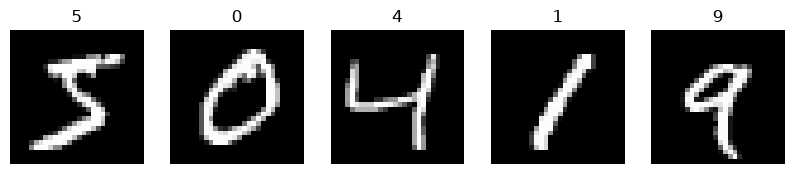

In [11]:
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms

mnist_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
mnist_test = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

print("train examples:", len(mnist_train))
print("test examples: ", len(mnist_test))

# Peek at a few examples
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    image, label = mnist_train[i]       # image is already a tensor of shape (1, 28, 28), scaled to 0-1
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.show()

In [12]:
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)

mnist_model = nn.Sequential(
    nn.Flatten(),                # 28x28 image -> a flat vector of 784 numbers
    nn.Linear(28 * 28, 128),
    nn.ReLU(),                   # a hidden layer that learns intermediate features
    nn.Linear(128, 10),          # 10 raw class scores (logits) -- no softmax; CrossEntropyLoss applies it internally
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mnist_model.parameters())

print(mnist_model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


In [13]:
for epoch in range(5):
    mnist_model.train()          # some layers (e.g. Dropout, BatchNorm) behave differently in train vs eval mode
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        logits = mnist_model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(mnist_train)
    print(f"epoch {epoch}: train_loss={train_loss:.4f}")

# Evaluate on the held-out test set
mnist_model.eval()
correct = 0
with torch.no_grad():   # we're not training here, so there's no need to track gradients at all
    for images, labels in test_loader:
        logits = mnist_model(images)
        predicted = logits.argmax(dim=1)   # pick the class with the highest score
        correct += (predicted == labels).sum().item()

test_accuracy = correct / len(mnist_test)
print(f"\ntest accuracy: {test_accuracy:.4f}")

epoch 0: train_loss=0.3411


epoch 1: train_loss=0.1550


epoch 2: train_loss=0.1076


epoch 3: train_loss=0.0821


epoch 4: train_loss=0.0652



test accuracy: 0.9769


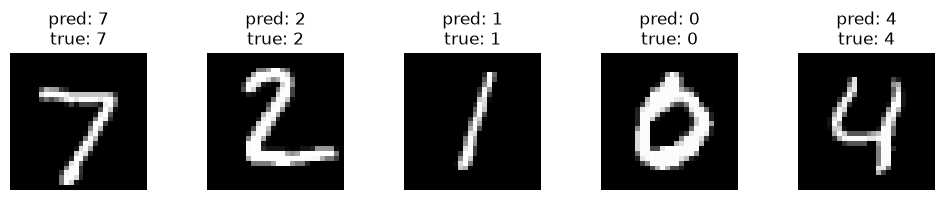

In [14]:
# Look at a handful of actual predictions vs. the true labels
mnist_model.eval()
sample_images = torch.stack([mnist_test[i][0] for i in range(5)])
sample_labels = [mnist_test[i][1] for i in range(5)]

with torch.no_grad():
    predicted_labels = mnist_model(sample_images).argmax(dim=1)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(sample_images[i].squeeze(0), cmap="gray")
    ax.set_title(f"pred: {predicted_labels[i].item()}\ntrue: {sample_labels[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Where to go from here

Comparable accuracy to the TensorFlow notebook's MNIST model, from an almost identical architecture — the two frameworks really do converge on the same ideas, just with different amounts of scaffolding removed. A few directions to keep exploring, same list as the TensorFlow notebook, now from the PyTorch side:

- **Convolutional layers (`nn.Conv2d`)** — look at local pixel patches instead of flattening immediately; the standard choice for image tasks and a likely path past 99% here.
- **Overfitting and regularization** — hold out a validation split (`torch.utils.data.random_split`), watch validation accuracy diverge from training accuracy with more epochs, and look into `nn.Dropout` as a countermeasure.
- **Saving/loading models** — `torch.save(model.state_dict(), path)` / `model.load_state_dict(torch.load(path))`, PyTorch's equivalent of `model.save()`/`load_model()`.
- **Writing your own `Dataset`** — subclass `torch.utils.data.Dataset` to load real files (images, CSVs) from disk on demand, rather than relying on a built-in dataset like MNIST.
- **PyTorch Lightning** — a popular higher-level wrapper that adds back something closer to Keras's `.fit()` convenience on top of raw PyTorch, once writing the training loop by hand starts to feel repetitive.